# Focused SVD Experiment: sim-only @ 512 alpha sweep

This notebook keeps the strongest current SVD setup fixed and sweeps only the interpolation weight `alpha`:

- weighting: `similarity`
- graph expansion: `none` (`sim-only`)
- SVD rank: `512`
- alpha: `0.00` to `1.00` in `0.05` steps

The goal is to test whether a light retuning of the dense/KG interpolation improves over the current `alpha = 0.5` setting without changing the underlying pipeline.

In [1]:
import os
import re
import unicodedata
from pathlib import Path
from typing import Dict, List, Tuple

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyterrier as pt
from scipy.sparse import csr_matrix
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

if not pt.java.started():
    pt.java.init()

def l2_normalize_rows(M: np.ndarray) -> np.ndarray:
    M = M.astype(np.float32, copy=False)
    denom = np.linalg.norm(M, axis=1, keepdims=True) + 1e-12
    return (M / denom).astype(np.float32)

def ensure_run(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["qid"] = df["qid"].astype(str)
    df["docno"] = df["docno"].astype(str)
    if "score" not in df.columns:
        df["score"] = 0.0
    df["score"] = df["score"].astype(float)
    if "rank" not in df.columns:
        df = df.sort_values(["qid", "score"], ascending=[True, False])
        df["rank"] = df.groupby("qid").cumcount() + 1
    return df

_ws_re = re.compile(r"\s+")
_tags_re = re.compile(r"<[^>]+>")

def normalize_text(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = _tags_re.sub(" ", s)
    s = unicodedata.normalize("NFKC", s)
    s = s.lower()
    s = re.sub(r"[^0-9a-zA-ZäöüßÄÖÜẞ]+", " ", s)
    s = _ws_re.sub(" ", s).strip()
    return s

def safe_concat(parts):
    clean = []
    for p in parts:
        if p is None:
            continue
        p = str(p)
        if p.strip() in ("", "N/A", "nan"):
            continue
        clean.append(p)
    return " ".join(clean)

def build_doc_text(row: pd.Series) -> str:
    return safe_concat([row.get("question"), row.get("choices_processed")])


/Users/user/miniconda3/envs/KG-re-ranking/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


In [2]:
PROJECT_ROOT = Path("/Users/user/Submissions/BEA-2026").resolve()
QB_PATH = PROJECT_ROOT / "qbank.csv"
QUERIES_PATH = PROJECT_ROOT / "queries.csv"
QRELS_PATH = PROJECT_ROOT / "qrels.tsv"
ESCO_DIR = PROJECT_ROOT / "ESCO"
SKILLS_PATH = ESCO_DIR / "skills_de.csv"

OUT_DIR = PROJECT_ROOT / "artifacts" / "svd_simonly_512_alpha_sweep"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = PROJECT_ROOT / "artifacts" / "svd_ablation"
BGE_ART_DIR = PROJECT_ROOT / "artifacts" / "bge_gemma_reranker"

DENSE_MODEL = "deutsche-telekom/gbert-large-paraphrase-cosine"
ESCO_MODEL = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

ESCO_TOPK_DOC = 15
ESCO_TOPK_QUERY = 20
ESCO_MIN_SIM = 0.45

K_CAND = 100
K_FINAL = 50
RANDOM_STATE = 42
SVD_DIM = 512
ALPHAS = [round(x, 2) for x in np.arange(0.0, 1.0001, 0.05)]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)
print("CACHE_DIR:", CACHE_DIR)
print("ALPHAS:", ALPHAS)

qb = pd.read_csv(QB_PATH).fillna("N/A")
queries = pd.read_csv(QUERIES_PATH).fillna("")
qrels = pd.read_csv(QRELS_PATH, sep="\t").fillna(0)

qb["docno"] = qb["test_item_id"].astype(str)
qb["raw_text"] = qb.apply(build_doc_text, axis=1)
qb["text"] = qb["raw_text"].map(normalize_text)
corpus = qb[["docno", "text"]].copy()

topics = queries.rename(columns={"queries": "query"})[["qid", "query"]].copy()
topics["qid"] = topics["qid"].astype(str)
topics["query"] = topics["query"].astype(str).map(normalize_text)

qrels = qrels.rename(columns={"rel": "label"})[["qid", "docno", "label"]].copy()
qrels["qid"] = qrels["qid"].astype(str)
qrels["docno"] = qrels["docno"].astype(str)
qrels["label"] = qrels["label"].astype(int)


PROJECT_ROOT: /Users/user/Submissions/BEA-2026
OUT_DIR: /Users/user/Submissions/BEA-2026/artifacts/svd_simonly_512_alpha_sweep
CACHE_DIR: /Users/user/Submissions/BEA-2026/artifacts/svd_ablation
ALPHAS: [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95), np.float64(1.0)]


In [3]:
class FaissDenseRetriever(pt.Transformer):
    def __init__(self, corpus_df: pd.DataFrame, model_name: str, topk: int):
        super().__init__()
        self.topk = int(topk)
        cdf = corpus_df[["docno", "text"]].copy()
        cdf["docno"] = cdf["docno"].astype(str)
        cdf["text"] = cdf["text"].astype(str)
        self.docnos = cdf["docno"].tolist()
        self.st = SentenceTransformer(model_name, device="cpu")
        xdoc = self.st.encode(
            cdf["text"].tolist(),
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=True,
        ).astype("float32")
        self.index = faiss.IndexFlatIP(xdoc.shape[1])
        self.index.add(xdoc)

    def transform(self, topics_df: pd.DataFrame) -> pd.DataFrame:
        qids = topics_df["qid"].astype(str).tolist()
        qs = topics_df["query"].astype(str).tolist()
        q = self.st.encode(
            qs,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).astype("float32")
        scores, idxs = self.index.search(q, self.topk)
        rows = []
        for i, qid in enumerate(qids):
            for rank, (j, sc) in enumerate(zip(idxs[i], scores[i]), start=1):
                if j < 0:
                    continue
                rows.append({"qid": qid, "docno": self.docnos[j], "score": float(sc), "rank": int(rank)})
        return pd.DataFrame(rows)

class StaticRunSource(pt.Transformer):
    def __init__(self, run_df: pd.DataFrame):
        super().__init__()
        self.run_df = ensure_run(run_df)

    def transform(self, topics_df: pd.DataFrame) -> pd.DataFrame:
        return self.run_df.copy()

class KGReranker(pt.Transformer):
    def __init__(self, qid2vec: Dict[str, np.ndarray], docno2vec: Dict[str, np.ndarray], alpha: float = 0.5):
        super().__init__()
        self.qid2vec = qid2vec
        self.docno2vec = docno2vec
        self.alpha = float(alpha)
        self.dim = int(next(iter(docno2vec.values())).shape[0])
        self.zero = np.zeros(self.dim, dtype=np.float32)

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = ensure_run(df)
        out = df.copy()
        out["orig_score"] = out["score"].astype(float)
        Q = np.vstack([self.qid2vec.get(q, self.zero) for q in out["qid"]]).astype(np.float32)
        D = np.vstack([self.docno2vec.get(d, self.zero) for d in out["docno"]]).astype(np.float32)
        kg = (l2_normalize_rows(Q) * l2_normalize_rows(D)).sum(axis=1).astype(np.float32)
        out["kg_score"] = kg.astype(float)
        out["score"] = ((1.0 - self.alpha) * out["kg_score"] + self.alpha * out["orig_score"]).astype(float)
        out = out.sort_values(["qid", "score"], ascending=[True, False])
        out["rank"] = out.groupby("qid").cumcount() + 1
        return out

def cut_k(k: int) -> pt.Transformer:
    return pt.apply.generic(lambda df: df.groupby("qid", sort=False).head(int(k)))

def eval_at_k(pipelines, topics_df, qrels_df, k_eval: int) -> pd.DataFrame:
    metrics = [
        f"ndcg_cut.{k_eval}",
        "recip_rank",
        f"P.{k_eval}",
        f"recall.{k_eval}",
        f"map_cut.{k_eval}",
    ]
    df = pt.Experiment(
        [p for _, p in pipelines],
        topics_df,
        qrels_df,
        eval_metrics=metrics,
        names=[n for n, _ in pipelines],
        verbose=True,
        validate="ignore",
    )
    df = df.rename(columns={
        f"ndcg_cut.{k_eval}": f"nDCG@{k_eval}",
        "recip_rank": f"MRR@{k_eval}",
        f"P.{k_eval}": f"Prec@{k_eval}",
        f"recall.{k_eval}": f"Recall@{k_eval}",
        f"map_cut.{k_eval}": f"MAP@{k_eval}",
    }).copy()
    p = df[f"Prec@{k_eval}"].astype(float)
    r = df[f"Recall@{k_eval}"].astype(float)
    df[f"F1@{k_eval}"] = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)
    cols = ["name", f"nDCG@{k_eval}", f"MRR@{k_eval}", f"Prec@{k_eval}", f"Recall@{k_eval}", f"F1@{k_eval}", f"MAP@{k_eval}"]
    return df[cols]

def to_table1_style(metrics_df: pd.DataFrame, ann_name: str, k_eval: int = 50) -> pd.DataFrame:
    df = metrics_df.copy()
    ann_ndcg = float(df.loc[df["name"] == ann_name, f"nDCG@{k_eval}"].iloc[0])
    df["Delta"] = df[f"nDCG@{k_eval}"].astype(float) - ann_ndcg
    df["Pct"] = np.where(ann_ndcg != 0, 100.0 * df["Delta"] / ann_ndcg, 0.0)
    out = pd.DataFrame({
        "Method": df["name"],
        "nDCG": df[f"nDCG@{k_eval}"].astype(float),
        "Delta": df["Delta"].astype(float),
        "%": df["Pct"].astype(float),
        "MRR": df[f"MRR@{k_eval}"].astype(float),
        "P": df[f"Prec@{k_eval}"].astype(float),
        "R": df[f"Recall@{k_eval}"].astype(float),
        "F1": df[f"F1@{k_eval}"].astype(float),
        "MAP": df[f"MAP@{k_eval}"].astype(float),
    })
    return out

def top_skills(texts: List[str], topk: int, st_model: SentenceTransformer, vocab: List[str], index) -> List[List[Tuple[str, float]]]:
    q = st_model.encode(
        [str(t) for t in texts],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    ).astype("float32")
    scores, idxs = index.search(q, int(topk))
    out = []
    for i in range(len(texts)):
        pairs = []
        for j, sc in zip(idxs[i], scores[i]):
            if j < 0:
                continue
            pairs.append((vocab[j], float(sc)))
        out.append(pairs)
    return out

def pairs_to_df(ids: List[str], pairs: List[List[Tuple[str, float]]], id_col: str) -> pd.DataFrame:
    rows = []
    for _id, ps in zip(ids, pairs):
        for uri, sc in ps:
            if float(sc) < float(ESCO_MIN_SIM):
                continue
            rows.append({id_col: str(_id), "skill_uri": str(uri), "w": float(sc)})
    df = pd.DataFrame(rows)
    if df.empty:
        df = pd.DataFrame(columns=[id_col, "skill_uri", "w"])
    return df

def build_svd_vectors(doc_df: pd.DataFrame, qid_df: pd.DataFrame, svd_dim: int):
    svd_skill_vocab = pd.Index(pd.concat([
        doc_df["skill_uri"].astype(str),
        qid_df["skill_uri"].astype(str),
    ])).unique().tolist()
    skill2idx = {u: i for i, u in enumerate(svd_skill_vocab)}
    n_sk = len(svd_skill_vocab)

    doc_ids = corpus["docno"].astype(str).unique().tolist()
    qid_ids = topics["qid"].astype(str).unique().tolist()
    doc2row = {d: i for i, d in enumerate(doc_ids)}
    qid2row = {q: i for i, q in enumerate(qid_ids)}

    def to_sparse(df, id_col, id2row):
        if df.empty:
            return csr_matrix((len(id2row), n_sk), dtype=np.float32)
        r = df[id_col].astype(str).map(id2row).to_numpy()
        c = df["skill_uri"].astype(str).map(skill2idx).to_numpy()
        v = df["w"].astype(float).to_numpy()
        return csr_matrix((v, (r, c)), shape=(len(id2row), n_sk), dtype=np.float32)

    X_doc = to_sparse(doc_df, "docno", doc2row)
    X_qid = to_sparse(qid_df, "qid", qid2row)

    max_dim = min(X_doc.shape[0] - 1, X_doc.shape[1] - 1)
    used_dim = max_dim if svd_dim >= max_dim else svd_dim
    svd = TruncatedSVD(n_components=used_dim, random_state=RANDOM_STATE)
    E_doc = normalize(svd.fit_transform(X_doc))
    E_qid = normalize(svd.transform(X_qid))
    explained = float(svd.explained_variance_ratio_.sum())
    docno2kg = {doc_ids[i]: E_doc[i].astype(np.float32) for i in range(len(doc_ids))}
    qid2kg = {qid_ids[i]: E_qid[i].astype(np.float32) for i in range(len(qid_ids))}
    return docno2kg, qid2kg, explained, used_dim

dense_cache = CACHE_DIR / "dense100_run.csv"
if dense_cache.exists():
    dense_run = pd.read_csv(dense_cache)
    print("Loaded cached dense run:", dense_cache)
else:
    dense100 = FaissDenseRetriever(corpus, model_name=DENSE_MODEL, topk=K_CAND)
    dense_run = dense100.transform(topics)
    dense_run.to_csv(dense_cache, index=False)
    print("Saved dense run:", dense_cache)

dense_run = ensure_run(dense_run)
dense_source = StaticRunSource(dense_run)
cut50 = cut_k(K_FINAL)

doc_skills_cache = CACHE_DIR / "doc_skills_df.csv"
qid_skills_cache = CACHE_DIR / "qid_skills_df.csv"

if doc_skills_cache.exists() and qid_skills_cache.exists():
    doc_skills_df = pd.read_csv(doc_skills_cache)
    qid_skills_df = pd.read_csv(qid_skills_cache)
    print("Loaded cached skill links")
else:
    skills_df = pd.read_csv(SKILLS_PATH).fillna("")
    skills_df["conceptUri"] = skills_df["conceptUri"].astype(str).str.strip()
    skills_df["preferredLabel"] = skills_df["preferredLabel"].astype(str).str.strip()
    skills_nn = skills_df[["conceptUri", "preferredLabel"]].drop_duplicates("conceptUri").copy()
    skills_nn = skills_nn[(skills_nn["conceptUri"] != "") & (skills_nn["conceptUri"] != "nan")]
    skills_nn = skills_nn[(skills_nn["preferredLabel"] != "") & (skills_nn["preferredLabel"] != "nan")].reset_index(drop=True)
    skill_vocab = skills_nn["conceptUri"].tolist()
    skill_labels = skills_nn["preferredLabel"].tolist()

    st_esco = SentenceTransformer(ESCO_MODEL, device="cpu")
    X = st_esco.encode(skill_labels, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True).astype("float32")
    index_esco = faiss.IndexFlatIP(X.shape[1])
    index_esco.add(X)

    doc_pairs = top_skills(corpus["text"].astype(str).tolist(), ESCO_TOPK_DOC, st_esco, skill_vocab, index_esco)
    qid_pairs = top_skills(topics["query"].astype(str).tolist(), ESCO_TOPK_QUERY, st_esco, skill_vocab, index_esco)
    doc_skills_df = pairs_to_df(corpus["docno"].astype(str).tolist(), doc_pairs, "docno")
    qid_skills_df = pairs_to_df(topics["qid"].astype(str).tolist(), qid_pairs, "qid")
    doc_skills_df.to_csv(doc_skills_cache, index=False)
    qid_skills_df.to_csv(qid_skills_cache, index=False)
    print("Saved skill-link caches")

doc_base = doc_skills_df.copy()
qid_base = qid_skills_df.copy()
doc_base["w"] = doc_base["w"].astype(float)
qid_base["w"] = qid_base["w"].astype(float)

docno2kg, qid2kg, explained, used_dim = build_svd_vectors(doc_base, qid_base, SVD_DIM)
print("used_dim:", used_dim)
print("explained_variance:", explained)


Loaded cached dense run: /Users/user/Submissions/BEA-2026/artifacts/svd_ablation/dense100_run.csv
Loaded cached skill links


used_dim: 512
explained_variance: 0.7728558778762817


pt.Experiment:   0%|          | 0/22 [00:00<?, ?system/s]

pt.Experiment:  36%|███▋      | 8/22 [00:00<00:00, 73.79system/s]

pt.Experiment:  77%|███████▋  | 17/22 [00:00<00:00, 79.14system/s]

pt.Experiment: 100%|██████████| 22/22 [00:00<00:00, 80.89system/s]

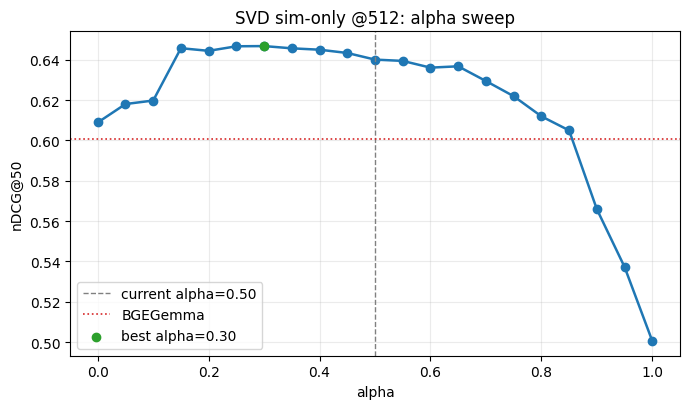

,alpha,nDCG,Delta,%,MRR,P,R,F1,MAP
0,0.00,0.6089,0.1083,21.6363,0.8593,0.5560,0.4745,0.5120,0.3606
1,0.05,0.6180,0.1175,23.4621,0.8706,0.5560,0.4745,0.5120,0.3721
2,0.10,0.6198,0.1192,23.8104,0.8708,0.5587,0.4767,0.5144,0.3742
3,0.15,0.6457,0.1451,28.9928,0.9042,0.5613,0.4790,0.5169,0.4088
4,0.20,0.6444,0.1438,28.7307,0.9039,0.5587,0.4774,0.5148,0.4079
5,0.25,0.6467,0.1461,29.1821,0.9039,0.5613,0.4804,0.5177,0.4097
6,0.30,0.6468,0.1462,29.2023,0.9042,0.5613,0.4814,0.5183,0.4105
7,0.35,0.6457,0.1451,28.9798,0.9044,0.5600,0.4806,0.5173,0.4100
8,0.40,0.6450,0.1444,28.8430,0.9044,0.5573,0.4793,0.5154,0.4091
9,0.45,0.6434,0.1428,28.5183,0.9044,0.5587,0.4800,0.5164,0.4083



Best row:

                                          Method     nDCG    Delta         %      MRR        P        R       F1      MAP  alpha
dense@100>>KG(SVD sim-only @512,alpha=0.30)->@50 0.646782 0.146186 29.202338 0.904167 0.561333 0.481352 0.518275 0.410514    0.3

Summary:

used_dim=512
explained_variance=0.772856
alpha_default=0.50
ndcg_default=0.640077
best_alpha=0.30
best_ndcg=0.646782
improvement_vs_default=+0.006705
bgegemma_ndcg=0.600791
margin_vs_bgegemma=+0.045991
n_alphas=21

Saved: /Users/user/Submissions/BEA-2026/artifacts/svd_simonly_512_alpha_sweep/svd_simonly_512_alpha_sweep_metrics_raw.csv
Saved: /Users/user/Submissions/BEA-2026/artifacts/svd_simonly_512_alpha_sweep/svd_simonly_512_alpha_sweep_table1_compare.csv
Saved: /Users/user/Submissions/BEA-2026/artifacts/svd_simonly_512_alpha_sweep/svd_simonly_512_alpha_sweep_by_alpha.csv
Saved: /Users/user/Submissions/BEA-2026/artifacts/svd_simonly_512_alpha_sweep/svd_simonly_512_alpha_sweep_best_row.csv
Saved: /Users/user/

In [4]:
pipelines = [("ANN@100->@50", dense_source >> cut50)]
for alpha in ALPHAS:
    kg = KGReranker(qid2kg, docno2kg, alpha=alpha)
    name = f"dense@100>>KG(SVD sim-only @512,alpha={alpha:.2f})->@50"
    pipelines.append((name, dense_source >> kg >> cut50))

metrics_df = eval_at_k(pipelines, topics, qrels, K_FINAL)
table_df = to_table1_style(metrics_df, ann_name="ANN@100->@50", k_eval=K_FINAL)
table_df = table_df.sort_values("nDCG", ascending=False).reset_index(drop=True)

alpha_rows = table_df[table_df["Method"].str.contains("KG\(SVD sim-only @512", regex=True)].copy()
alpha_rows["alpha"] = alpha_rows["Method"].str.extract(r"alpha=([0-9.]+)").astype(float)
alpha_rows = alpha_rows.sort_values("alpha").reset_index(drop=True)

bge_path = BGE_ART_DIR / "bge_gemma_reranker_table1_row.csv"
bge_ref = pd.read_csv(bge_path)
bge_ndcg = float(bge_ref["nDCG"].iloc[0])

best_row = alpha_rows.sort_values("nDCG", ascending=False).iloc[0].copy()
alpha05_row = alpha_rows.loc[np.isclose(alpha_rows["alpha"], 0.50)].iloc[0].copy()
best_alpha = float(best_row["alpha"])
best_ndcg = float(best_row["nDCG"])
alpha05_ndcg = float(alpha05_row["nDCG"])

best_run = (dense_source >> KGReranker(qid2kg, docno2kg, alpha=best_alpha) >> cut50).transform(topics)

metrics_path = OUT_DIR / "svd_simonly_512_alpha_sweep_metrics_raw.csv"
compare_path = OUT_DIR / "svd_simonly_512_alpha_sweep_table1_compare.csv"
alpha_path = OUT_DIR / "svd_simonly_512_alpha_sweep_by_alpha.csv"
best_row_path = OUT_DIR / "svd_simonly_512_alpha_sweep_best_row.csv"
best_run_path = OUT_DIR / "svd_simonly_512_alpha_sweep_best_run.csv"
summary_path = OUT_DIR / "svd_simonly_512_alpha_sweep_summary.txt"
plot_path = OUT_DIR / "svd_simonly_512_alpha_sweep_ndcg.png"

metrics_df.to_csv(metrics_path, index=False)
table_df.to_csv(compare_path, index=False)
alpha_rows.to_csv(alpha_path, index=False)
pd.DataFrame([best_row]).to_csv(best_row_path, index=False)
best_run.to_csv(best_run_path, index=False)

summary_lines = [
    f"used_dim={used_dim}",
    f"explained_variance={explained:.6f}",
    f"alpha_default=0.50",
    f"ndcg_default={alpha05_ndcg:.6f}",
    f"best_alpha={best_alpha:.2f}",
    f"best_ndcg={best_ndcg:.6f}",
    f"improvement_vs_default={best_ndcg - alpha05_ndcg:+.6f}",
    f"bgegemma_ndcg={bge_ndcg:.6f}",
    f"margin_vs_bgegemma={best_ndcg - bge_ndcg:+.6f}",
    f"n_alphas={len(ALPHAS)}",
]
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

plt.figure(figsize=(7.0, 4.2))
plt.plot(alpha_rows["alpha"], alpha_rows["nDCG"], marker="o", linewidth=1.8)
plt.axvline(0.50, color="gray", linestyle="--", linewidth=1.0, label="current alpha=0.50")
plt.axhline(bge_ndcg, color="tab:red", linestyle=":", linewidth=1.2, label="BGEGemma")
plt.scatter([best_alpha], [best_ndcg], color="tab:green", zorder=3, label=f"best alpha={best_alpha:.2f}")
plt.xlabel("alpha")
plt.ylabel("nDCG@50")
plt.title("SVD sim-only @512: alpha sweep")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(plot_path, dpi=160)
plt.show()

display(alpha_rows[["alpha", "nDCG", "Delta", "%", "MRR", "P", "R", "F1", "MAP"]].round(4))
print("\nBest row:\n")
print(pd.DataFrame([best_row]).to_string(index=False))
print("\nSummary:\n")
print("\n".join(summary_lines))
print("\nSaved:", metrics_path)
print("Saved:", compare_path)
print("Saved:", alpha_path)
print("Saved:", best_row_path)
print("Saved:", best_run_path)
print("Saved:", summary_path)
print("Saved:", plot_path)
